In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import ehtim as eh

import jax
from jax import numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
from skimage import data, transform
from utils import NeuralImage, train_step, train_step_hetero


Welcome to eht-imaging! v 1.2.10 



Loading text image:  datasets/avery_sgra_eofn.txt


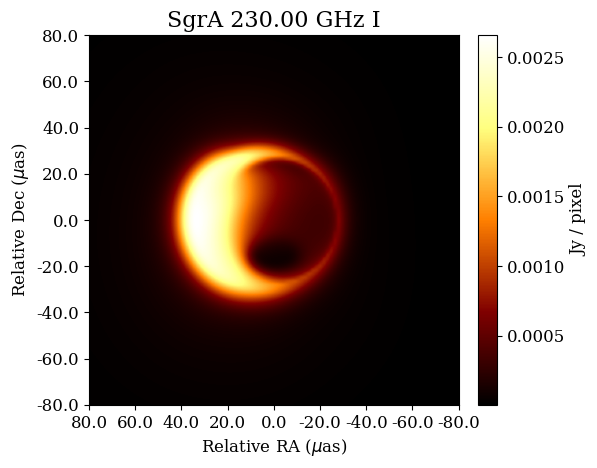

In [2]:
image_path = 'data/images/avery_sgra_eofn.txt'
array_path = 'data/vlbi/EHT2017.txt'
image_true = eh.image.load_txt(image_path)
array = eh.array.load_txt(array_path)
image_true.display()

intensity_gt = jnp.array(image_true.imarr(), dtype=jnp.float32)
ydim, xdim = intensity_gt.shape
assert intensity_gt.size == image_true.imvec.size

x, y = np.linspace(0, 1, xdim), np.linspace(0, 1, ydim)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='xy')), 0, -1)

coords_flat = coords.reshape(-1,2)
gt_flat = intensity_gt.ravel()

In [ ]:
mask = coords_flat[:, 0] > 0.5
coords_train = coords_flat[~mask]
Y_train_true = gt_flat[~mask] # no noise applied

coords_test = coords_flat[mask]
Y_test_true = gt_flat[mask] #no noise applied

: 

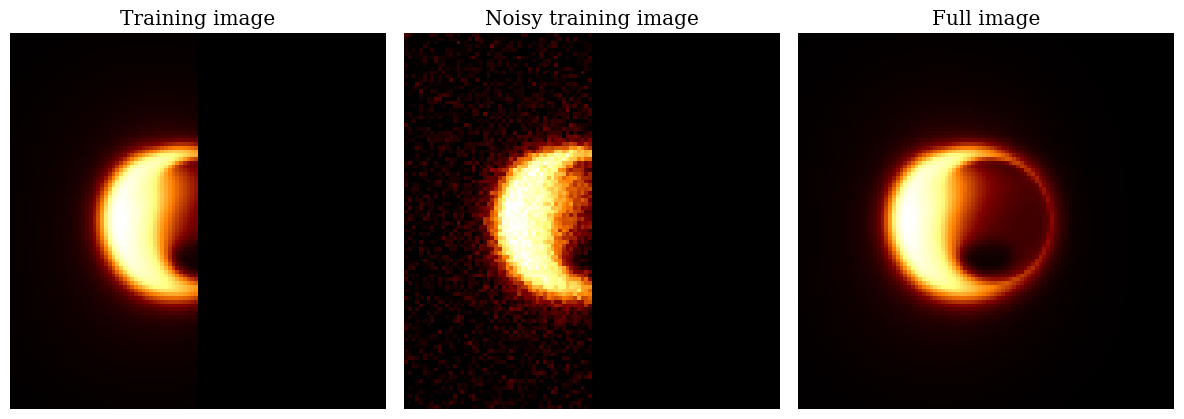

: 

In [ ]:
rng = jax.random.PRNGKey(42)
noise = 0.05 * jnp.max(jnp.abs(Y_train_true))

#add gaussian noise
Y_train = Y_train_true + noise * jax.random.normal(rng, Y_train_true.shape)
sigma_vec = jnp.full_like(Y_train, noise)

# plot
full_clean = jnp.zeros(xdim*ydim)
full_noisy = jnp.zeros(xdim*ydim)

full_clean = full_clean.at[~mask].set(Y_train_true)
full_noisy = full_noisy.at[~mask].set(Y_train)

I_clean = full_clean.reshape(ydim, xdim)
I_noisy = full_noisy.reshape(ydim, xdim)

vmin, vmax = float(I_clean.min()), float(I_clean.max())
fig, ax = plt.subplots(1,3, figsize=(12,6))
ax[0].imshow(I_clean, cmap='afmhot', vmin=vmin, vmax=vmax, origin='upper')
ax[0].set_title("Training image")
ax[1].imshow(I_noisy, cmap='afmhot', vmin=vmin, vmax=vmax, origin='upper')
ax[1].set_title("Noisy training image")
ax[2].imshow(intensity_gt, cmap='afmhot')
ax[2].set_title("Full image")

for a in ax: 
    a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
predictor = NeuralImage(posenc_deg=3, net_depth=4, net_width=128, activation=nn.relu, out_channel=1, do_skip=True)

hparams = {'num_iters': 10000, 'lr_init': 1e-3, 'lr_final': 1e-4, 'batchsize': 1000}

params = predictor.init(rng, coords)['params']
tx = optax.adam(learning_rate=optax.polynomial_schedule(hparams['lr_init'], hparams['lr_final'], 1, hparams['num_iters']))
state = train_state.TrainState.create(apply_fn=predictor.apply, params=params, tx=tx)

for i in tqdm(range(hparams['num_iters']), desc='iteration'):
    batch = np.random.choice(range(len(coords_train)), hparams['batchsize'], replace=False)
    loss, state, image = train_step(state, Y_train[batch], coords_train[batch])
    if i % 1000 == 0:
        print(f"iteration {i}, loss={loss:.5f}")


iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

iteration 0, loss=0.58522
iteration 1000, loss=0.00000
iteration 2000, loss=0.00000
iteration 3000, loss=0.00000
iteration 4000, loss=0.00000
iteration 5000, loss=0.00000
iteration 6000, loss=0.00000
iteration 7000, loss=0.00000
iteration 8000, loss=0.00000
iteration 9000, loss=0.00000


: 

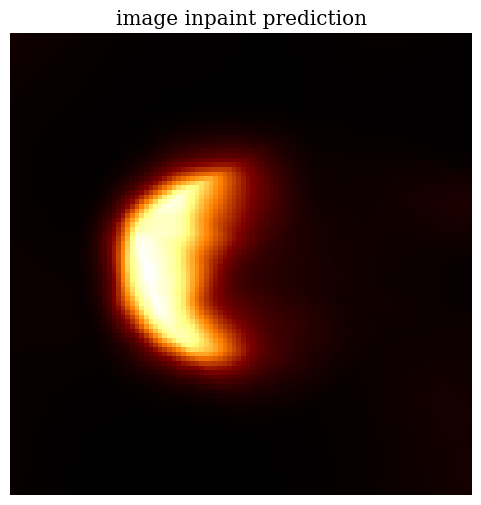

: 

In [ ]:
full_image = predictor.apply({'params': state.params}, coords)
full_image = np.array(full_image)
plt.figure(figsize=(6,6))
plt.imshow(full_image, cmap='afmhot', origin='upper')
plt.axis('off')
plt.title('image inpaint prediction')
plt.show()

In [10]:
def bilinear(coords, theta):
    """gpt generated function to fill in for now"""
    gx, gy, _ = theta.shape
    # scale to vertex index space
    x = coords[..., 0] * (gx - 1)
    y = coords[..., 1] * (gy - 1)

    i0 = jnp.floor(x).astype(jnp.int32)
    j0 = jnp.floor(y).astype(jnp.int32)
    i1 = jnp.clip(i0 + 1, 0, gx - 1)
    j1 = jnp.clip(j0 + 1, 0, gy - 1)

    wx = x - i0
    wy = y - j0

    # gather four corners
    t00 = theta[i0, j0]      # lower-left
    t10 = theta[i1, j0]      # lower-right
    t01 = theta[i0, j1]      # upper-left
    t11 = theta[i1, j1]      # upper-right

    return ((1 - wx) * (1 - wy))[..., None] * t00 + \
           (     wx  * (1 - wy))[..., None] * t10 + \
           ((1 - wx) *      wy )[..., None] * t01 + \
           (     wx  *      wy )[..., None] * t11

class DeformationGrid(nn.Module):
    resolution: tuple[int, ...]

    @nn.compact
    def __call__(self, coords):
        theta = self.param(
            'theta', 
            nn.initializers.zeros, 
            self.resolution + (coords.shape[-1],)
        )
        return bilinear(coords, theta)

def forward_with_deform(params_img, params_def, coords):
    offsets = DeformationGrid.apply({'params': params_def}, coords)
    return predictor.apply({'params': params_img}, coords + offsets)

grid_res = (72, 72)
def_grid = DeformationGrid(grid_res)

In [ ]:
"""prepare variables for bayes rays"""
npix = ydim
params_def = def_grid.init(
    jax.random.PRNGKey(0),
    jnp.array([[0, 0]]))['params']
params_def = jax.tree_util.tree_map(jnp.zeros_like, params_def)

params_img = state.params
params_img_frozen = jax.tree_util.tree_map(jnp.array, params_img)

: 

$$I(\theta) = \frac{4}{\sigma^2} \sum_n J^TJ

In [11]:
#implement bayes rays
def forward_offset(params_def, coords):
    """
    add offset and get updated visibility matrix
    """
    offsets = def_grid.apply({'params': params_def}, coords)
    img_pred = predictor.apply({'params': params_img_frozen}, coords + offsets)
    return img_pred

def f_scalar(params_def, coord):
    return forward_offset(params_def, coord[None, :])[0]

def grad_row(params_def, coord):
    g_tree = jax.grad(f_scalar)(params_def, coord)
    return g_tree['theta']

@jax.jit
def chunk(params_def, coords_batch):
    jacobian = jax.vmap(grad_row, in_axes=(None, 0))(params_def, coords_batch)
    return jnp.sum(jacobian**2, axis=0) 

def fisher_sum(chunk_size, res):
    """
    Args:
        chunk_size: number of rows of the jacobian to evaluate in one step
        res: grid resolution, (xdim, ydim); 2D for now
    Returns:
        J_sq: = sum( (J_re_n^2 + J_im_n^2) / sigma_n^2)
    """
    J_sq = jnp.zeros((res[0], res[1], 2))
    nvis = coords_train.shape[0]
    for start in range(0, nvis, chunk_size):
        end = min(start + chunk_size, nvis)
        J_sq += chunk(params_def, coords_train[start:end])
    return J_sq

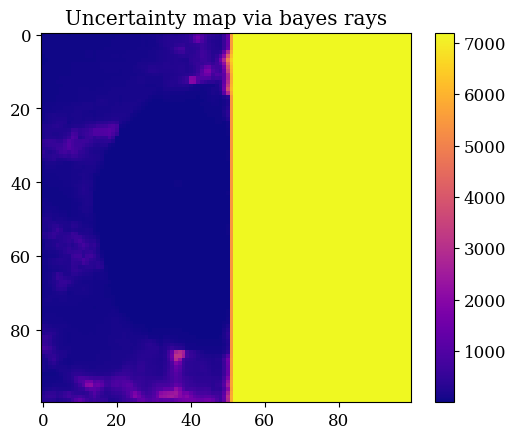

: 

In [ ]:
chunk_size = 8
J_sq = fisher_sum(chunk_size, grid_res)

lam = 1e-4 / (grid_res[0]*grid_res[1])
H_diag = (4/noise**2)*(J_sq/coords_flat.shape[0]) + 2.0 * lam # deterministic H, no monte carlo
variance_grid = 1 / H_diag
sigma_map = jnp.linalg.norm(
    jnp.sqrt(bilinear(coords, variance_grid)), 
    axis=-1
)

plt.figure()
plt.imshow(sigma_map, cmap='plasma')
plt.title("Uncertainty map via bayes rays")
plt.colorbar()
plt.show()

[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]


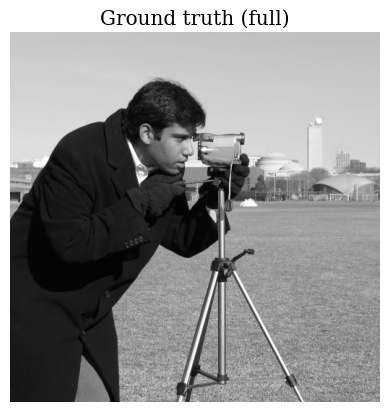

In [ ]:
# load datasets
img = data.camera()
H, W = img.shape
print(img)
intensity_gt = img.astype(jnp.float32) / 255.0
plt.figure()
plt.title('Ground truth (full)')
plt.imshow(img, cmap = plt.cm.gray)
plt.axis('off')
plt.show()

# hold out half
x = np.linspace(0, 1, W) # (x, y) \in [-1, 1]^2
y = np.linspace(0, 1, H)
coords = np.stack(np.meshgrid(x, y, indexing='xy'), axis = -1)

#hold out half of the coords by shuffling indices
coords_flat = coords.reshape(-1, 2)
gt_flat = intensity_gt.reshape(-1)



[  0 102 204 307 409 512]
[0.1 0.1 0.1 ... 0.8 0.8 0.8]


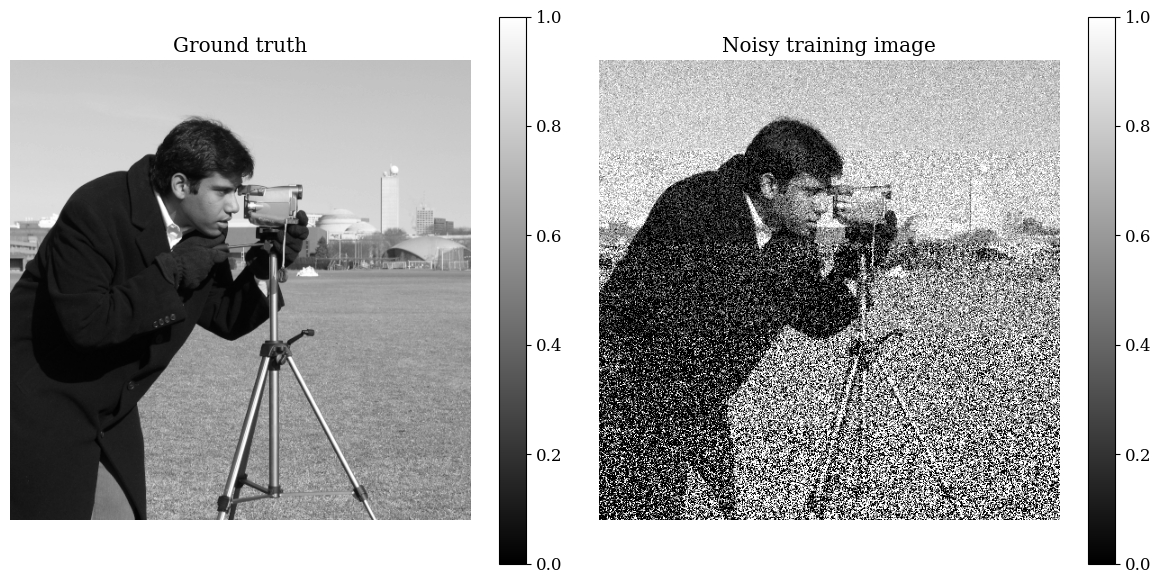

In [60]:
# bayes rays with heteroskedastic noise
ydim, xdim = intensity_gt.shape
band_edges = np.linspace(0, ydim, 6, dtype=int)
print(band_edges)
sigma_mat = jnp.zeros_like(intensity_gt)
sigmas = [1e-1, 2e-1, 4e-1, 6e-1, 8e-1]
for i in range(len(sigmas)):
    top, bottom = band_edges[i], band_edges[i+1]
    sigma_mat = sigma_mat.at[top:bottom, :].set(sigmas[i])

sigma_vec = sigma_mat.ravel()
print(sigma_vec)
rng = jax.random.PRNGKey(0)
#sigma_vec = jnp.linspace(0.00005, 0.0005, gt_flat.shape[0])
coords_train = coords_flat
Y_train_true = gt_flat
Y_train = Y_train_true + sigma_vec*jax.random.normal(rng, Y_train_true.shape) #add pixel-wise gaussian noise
# visualize and plot
vmin, vmax = float(Y_train_true.min()), float(Y_train_true.max())
fig, ax = plt.subplots(1, 2, figsize=(12,6))
im_0 = ax[0].imshow(Y_train_true.reshape(ydim, xdim), vmax=vmax, vmin=vmin, cmap='gray', origin='upper')
ax[0].set_title("Ground truth")
im_1 = ax[1].imshow(Y_train.reshape(ydim, xdim), vmin=vmin, vmax=vmax, cmap='gray', origin='upper')
ax[1].set_title("Noisy training image")
ax[0].axis('off')
ax[1].axis('off')
fig.colorbar(im_0, ax=ax[0])
fig.colorbar(im_1, ax=ax[1])
plt.tight_layout()
plt.show()

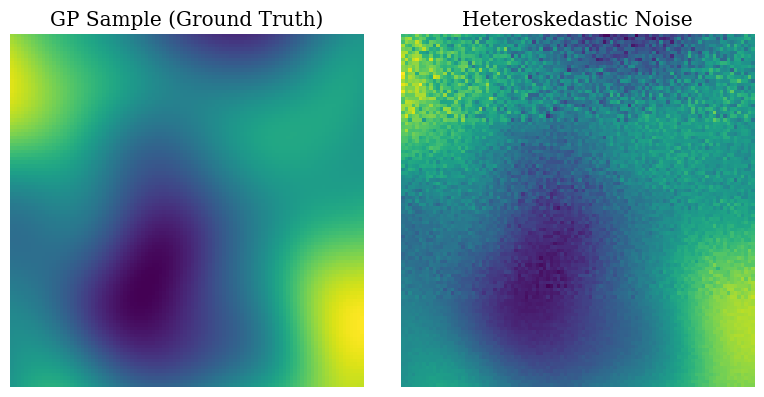

In [81]:
"""gaussian process example"""

# 1) Generate a 2D Gaussian process sample on a grid
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='xy')), 0, -1)
coords_flat = coords.reshape(-1, 2)

# RBF kernel
def rbf(a, b, ls):
    diff = a[:, None, :] - b[None, :, :]
    sqdist = np.sum(diff**2, axis=-1)
    return np.exp(-0.5 * sqdist / ls**2)

lengthscale = 0.2
K = rbf(coords_flat, coords_flat, lengthscale) + 1e-6 * np.eye(nx * ny)

# Sample from GP via Cholesky
L = np.linalg.cholesky(K)
gp_sample = L @ np.random.randn(nx * ny)
gp_img = gp_sample.reshape(ny, nx)

# Normalize to [0,1]
gp_img = (gp_img - gp_img.min()) / (gp_img.max() - gp_img.min())

# 2) Apply heteroskedastic noise in horizontal bands
band_edges = np.linspace(0, ny, 5, dtype=int)  # 5 bands
sigmas = [0.01, 0.03, 0.05, 0.1]
sigma_mat = np.zeros((ny, nx))
for i in range(len(sigmas)):
    top, bottom = band_edges[i], band_edges[i+1]
    sigma_mat[top:bottom, :] = sigmas[i]

# Add pixel-wise Gaussian noise
sigma_vec = sigma_mat.ravel()
noise = sigma_mat.ravel() * np.random.randn(nx * ny)
noisy_img = (gp_img.ravel() + noise).reshape(ny, nx)

# 3) Display the clean GP sample and the heteroskedastic noisy version
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gp_img, cmap='viridis', origin='lower')
axes[0].set_title("GP Sample (Ground Truth)")
axes[0].axis('off')
axes[1].imshow(noisy_img, cmap='viridis', origin='lower')
axes[1].set_title("Heteroskedastic Noise")
axes[1].axis('off')
plt.tight_layout()
plt.show()

coords_train = coords.reshape(-1,2)
gt_flat = gp_img.ravel()
Y_train_true = gt_flat
Y_train = noisy_img.ravel()


In [82]:
predictor = NeuralImage(posenc_deg=3, net_depth=5, net_width=128, activation=nn.relu, out_channel=1, do_skip=True)

hparams = {'num_iters': 9000, 'lr_init': 1e-3, 'lr_final': 1e-5, 'batchsize': 1000}

params = predictor.init(rng, coords)['params']
tx = optax.adam(learning_rate=optax.polynomial_schedule(hparams['lr_init'], hparams['lr_final'], 1, hparams['num_iters']))
state = train_state.TrainState.create(apply_fn=predictor.apply, params=params, tx=tx)

for i in tqdm(range(hparams['num_iters']), desc='iteration'):
    batch = np.random.choice(range(len(coords_train)), hparams['batchsize'], replace=False)
    loss, state, image = train_step_hetero(state, Y_train[batch], coords_train[batch], sigma_vec[batch]) #or just train_step(...,coords_train[batch])
    if i % 1000 == 0:
        print(f"iteration {i}, loss={float(loss):.9f}")


iteration:   0%|          | 0/9000 [00:00<?, ?it/s]

iteration 0, loss=349.775085449
iteration 1000, loss=0.993828654
iteration 2000, loss=1.034717798
iteration 3000, loss=0.992748678
iteration 4000, loss=0.954448879
iteration 5000, loss=0.956281543
iteration 6000, loss=0.989437521
iteration 7000, loss=0.844828188
iteration 8000, loss=0.984649837


In [88]:
"""prepare variables for bayes rays"""
grid_res = (2**6, 2**6)
def_grid = DeformationGrid(grid_res)
npix = ydim
params_def = def_grid.init(
    jax.random.PRNGKey(0),
    jnp.array([[0, 0]]))['params']
params_def = jax.tree_util.tree_map(jnp.zeros_like, params_def)

params_img = state.params
params_img_frozen = jax.tree_util.tree_map(jnp.array, params_img)

In [84]:
@jax.jit
def chunk_hetero(params_def, coords_batch, sigma_batch):
    jacobian = jax.vmap(grad_row, in_axes=(None, 0))(params_def, coords_batch)
    sigma_reshaped = sigma_batch.reshape((sigma_batch.shape[0],) + (1,) * (jacobian.ndim-1))
    jacobian_scaled = jacobian / sigma_reshaped
    return jnp.sum(jacobian_scaled**2, axis=0) 

def fisher_sum_hetero(chunk_size, res):
    """
    Args:
        chunk_size: number of rows of the jacobian to evaluate in one step
        res: grid resolution, (xdim, ydim); 2D for now
    Returns:
        J_sq: = sum( (J_re_n^2 + J_im_n^2) / sigma_n^2)
    """
    J_sq = jnp.zeros((res[0], res[1], 2))
    nvis = coords_train.shape[0]
    for start in range(0, nvis, chunk_size):
        end = min(start + chunk_size, nvis)
        J_sq += chunk_hetero(params_def, coords_train[start:end], sigma_vec[start:end])
    return J_sq

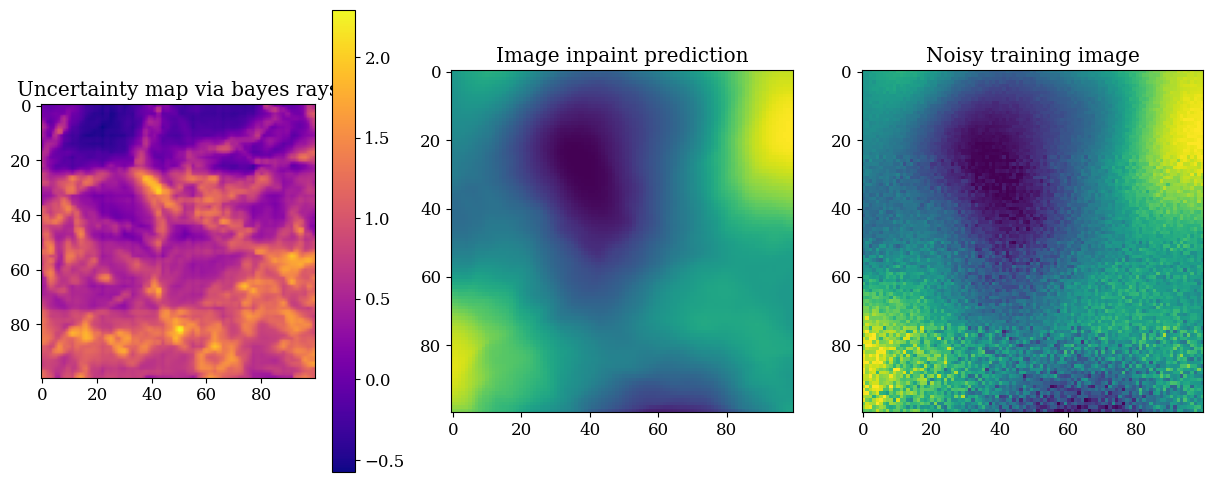

In [89]:
chunk_size = 32
J_sq = fisher_sum_hetero(chunk_size, grid_res)

lam = 1e-4 / (grid_res[0]*grid_res[1])
H_diag = (4/coords_flat.shape[0])*(J_sq) + 2.0 * lam # deterministic H, no monte carlo
variance_grid = 1 / H_diag
sigma_map = jnp.linalg.norm(
    jnp.sqrt(bilinear(coords, variance_grid)), 
    axis=-1
)

full_image = predictor.apply({'params': state.params}, coords)
full_image = np.array(full_image)


fig, ax = plt.subplots(1, 3, figsize=(15,6))
im_0 = ax[0].imshow(jnp.log10(sigma_map + 1e-12), cmap='plasma', origin="upper")
ax[0].set_title("Uncertainty map via bayes rays")
im_1 = ax[1].imshow(full_image, cmap='viridis', origin='upper')
ax[1].set_title('Image inpaint prediction')
im_2 = ax[2].imshow(Y_train.reshape(100, 100), vmin=vmin, vmax=vmax, cmap='viridis', origin='upper')
ax[2].set_title('Noisy training image')
plt.tight_layout
fig.colorbar(im_0, ax=ax[0])